In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 🧠 Long Short-Term Memory (LSTM) Model for Network Intrusion Detection

This notebook implements a Long Short-Term Memory (LSTM) neural network to classify network traffic into seven categories using the CICDDoS2019 dataset.

The objective is to evaluate the ability of recurrent neural networks to learn patterns from preprocessed network flow features and compare their performance with Deep Neural Network (DNN) and Convolutional Neural Network (CNN) models.

## 📚 1. Import Required Libraries


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib


from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization,
    Input,
    LSTM
)

## 💾 2. Load Preprocessed Datasets


In [3]:
X_train = np.load(
    '/content/drive/MyDrive/IDS_Project/data/X_train.npy'
)

y_train = np.load(
    '/content/drive/MyDrive/IDS_Project/data/y_train.npy'
)

X_test = np.load(
    '/content/drive/MyDrive/IDS_Project/data/X_test.npy'
)

y_test = np.load(
    '/content/drive/MyDrive/IDS_Project/data/y_test.npy'
)

In [4]:
)

label_encoder = joblib.load(
    '/content/drive/MyDrive/IDS_Project/data/label_encoder.pkl'
)

## 3. Reshape Features for LSTM Input


In [5]:
X_train_lstm = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test_lstm = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

## 🔀 4. Training and Validation Split

In [6]:
X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
    X_train_lstm,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

## 🏗️ 5. LSTM Model Architecture

In [ ]:
K.clear_session()


In [7]:
lstm_model = Sequential([

    Input(shape=(X_train_lstm.shape[1], 1)),

    LSTM(
        64,
        return_sequences=True
    ),

    Dropout(0.2),

    LSTM(
        32
    ),

    Dropout(0.2),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        7,
        activation='softmax'
    )

])

In [8]:
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 27, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 27, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,599 (119.53 KB)

 Trainable params: 30,599 (119.53 KB)

 Non-trainable params: 0 (0.00 B)

## ⚙️ 6. Model Compilation

In [9]:
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 📌 7. Training Strategy

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_lstm_model_7_classes.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

## 🚀 8. Model Training

In [12]:
history = lstm_model.fit(

    X_train_sub,
    y_train_sub,

    validation_data=(
        X_val_sub,
        y_val_sub
    ),

    epochs=20,

    batch_size=64,

    callbacks=[
        early_stop,
        checkpoint
    ],

    verbose=1
)

Epoch 1/20
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5769 - loss: 0.9703
Epoch 1: val_accuracy improved from None to 0.68283, saving model to best_lstm_model_7_classes.h5



Epoch 1: finished saving model to best_lstm_model_7_classes.h5
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 73s 39ms/step - accuracy: 0.6416 - loss: 0.7796 - val_accuracy: 0.6828 - val_loss: 0.6432
Epoch 2/20
1709/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6778 - loss: 0.6507
Epoch 2: val_accuracy improved from 0.68283 to 0.68718, saving model to best_lstm_model_7_classes.h5



Epoch 2: finished saving model to best_lstm_model_7_classes.h5
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 68s 40ms/step - accuracy: 0.6817 - loss: 0.6341 - val_accuracy: 0.6872 - val_loss: 0.5735
Epoch 3/20
1709/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6933 - loss: 0.5610
Epoch 3: val_accuracy improved from 0.68718 to 0.70842, saving model to best_lstm_model_7_classes.h5



Epoch 3: finished saving model to best_lstm_model_7_classes.h5
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 66s 38ms/step - accuracy: 0.6975 - loss: 0.5531 - val_accuracy: 0.7084 - val_loss: 0.5302
Epoch 4/20
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7016 - loss: 0.5465
Epoch 4: val_accuracy did not improve from 0.70842
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 66s 39ms/step - accuracy: 0.7031 - loss: 0.5414 - val_accuracy: 0.7049 - val_loss: 0.5263
Epoch 5/20
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7051 - loss: 0.5391
Epoch 5: val_accuracy improved from 0.70842 to 0.70952, saving model to best_lstm_model_7_classes.h5



Epoch 5: finished saving model to best_lstm_model_7_classes.h5
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 71s 42ms/step - accuracy: 0.7046 - loss: 0.5371 - val_accuracy: 0.7095 - val_loss: 0.5253
Epoch 6/20
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7027 - loss: 0.5352
Epoch 6: val_accuracy did not improve from 0.70952
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 66s 39ms/step - accuracy: 0.7034 - loss: 0.5344 - val_accuracy: 0.6977 - val_loss: 0.5479
Epoch 7/20
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7039 - loss: 0.5334
Epoch 7: val_accuracy did not improve from 0.70952
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 72s 42ms/step - accuracy: 0.7060 - loss: 0.5299 - val_accuracy: 0.7070 - val_loss: 0.5165
Epoch 8/20
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7050 - loss: 0.5292
Epoch 8: val_accuracy did not improve from 0.70952
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 66s 38ms/step - accuracy: 0.7073 - loss: 0.5270 - val_accuracy: 0.7070 - val_loss: 0.5158
Epoch 9/20
1709/1710 ━━━━━━━━━━━


Epoch 11: finished saving model to best_lstm_model_7_classes.h5
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 67s 39ms/step - accuracy: 0.7063 - loss: 0.5209 - val_accuracy: 0.7149 - val_loss: 0.5116
Epoch 12/20
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7095 - loss: 0.5208
Epoch 12: val_accuracy did not improve from 0.71485
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 67s 39ms/step - accuracy: 0.7089 - loss: 0.5189 - val_accuracy: 0.7135 - val_loss: 0.5087
Epoch 13/20
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7110 - loss: 0.5149
Epoch 13: val_accuracy improved from 0.71485 to 0.71920, saving model to best_lstm_model_7_classes.h5



Epoch 13: finished saving model to best_lstm_model_7_classes.h5
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 66s 39ms/step - accuracy: 0.7100 - loss: 0.5171 - val_accuracy: 0.7192 - val_loss: 0.5053
Epoch 14/20
1709/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7119 - loss: 0.5160
Epoch 14: val_accuracy did not improve from 0.71920
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 67s 39ms/step - accuracy: 0.7108 - loss: 0.5164 - val_accuracy: 0.7143 - val_loss: 0.5052
Epoch 15/20
1709/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7082 - loss: 0.5137
Epoch 15: val_accuracy did not improve from 0.71920
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 69s 40ms/step - accuracy: 0.7095 - loss: 0.5133 - val_accuracy: 0.7064 - val_loss: 0.5090
Epoch 16/20
1709/1710 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7087 - loss: 0.5131
Epoch 16: val_accuracy did not improve from 0.71920
1710/1710 ━━━━━━━━━━━━━━━━━━━━ 67s 39ms/step - accuracy: 0.7093 - loss: 0.5129 - val_accuracy: 0.7056 - val_loss: 0.5072
Epoch 17/20
1709/1710 ━━━

## 📊 9. Model Evaluation

In [13]:
test_loss, test_acc = lstm_model.evaluate(
    X_test_lstm,
    y_test,
    verbose=0
)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.9090
Test Loss: 0.3918


## 🔮 Generating Predictions

In [14]:
y_pred_probs = lstm_model.predict(X_test_lstm)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

1268/1268 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step


## 10. Classification Performance

In [15]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

               precision    recall  f1-score   support

       BENIGN       0.96      0.98      0.97     10873
   DrDoS_LDAP       0.85      0.97      0.90       978
  DrDoS_MSSQL       0.30      0.13      0.18      1860
DrDoS_NetBIOS       0.01      0.03      0.01       503
    DrDoS_UDP       0.99      0.89      0.94      8602
          Syn       1.00      0.99      0.99     17297
      UDP-lag       0.21      0.38      0.27       455

     accuracy                           0.91     40568
    macro avg       0.62      0.63      0.61     40568
 weighted avg       0.93      0.91      0.92     40568



## 📌 11. Confusion Matrix

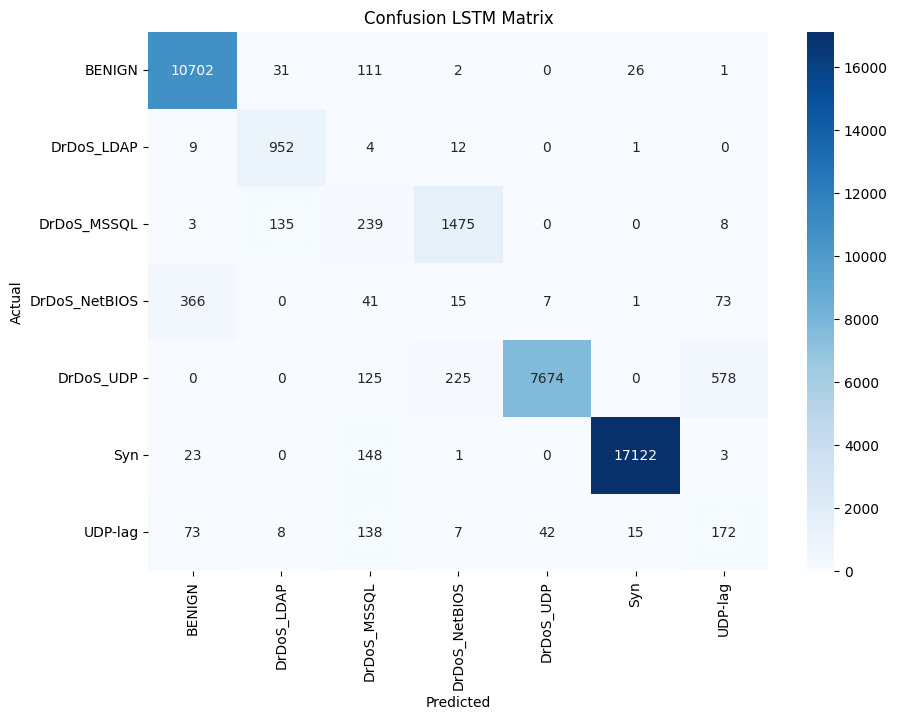

In [17]:
class_names = label_encoder.classes_

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion LSTM Matrix")

plt.show()

## 📈 12. Training and Validation Curves

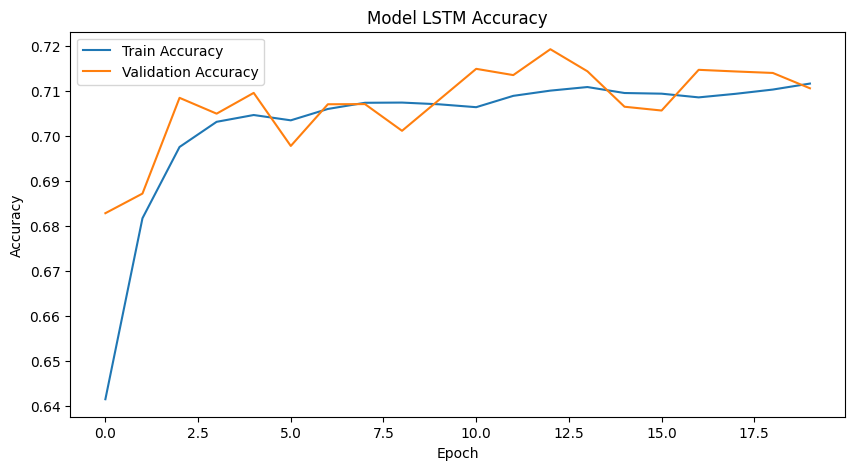

In [18]:
# Plot training history
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'],
         label='Train Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.title('Model LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

## 💾 13. Saving the Trained Model

In [19]:
import pickle

with open('LSTM_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

In [20]:
metrics = {
    'accuracy': test_acc,
    'loss': test_loss
}

with open('LSTM_metrics.pkl', 'wb') as f:
    pickle.dump(metrics, f)

In [21]:
np.save('LSTM_pred.npy', y_pred)